### Imports

In [1]:
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import numpy as np
import pickle
from models import RobotsSystem, Proportional_Controller, ClosedLoopSystem, RNNModel, RNNSystemIdentificationModel
from contractive_REN import ContractiveREN
from utils import set_params_robot
from dataset import SystemIdentificationDataset
from torch.utils.data import DataLoader, random_split
from scipy.stats import norm
import seaborn as sns
import os, sys, time
from datetime import datetime

### Simulation parameters

In [2]:
# Define simulation parameters
seed, x0, input_dim, state_dim, output_dim, input_noise_std, output_noise_std, n_agents, horizon, num_signals, train_size, val_size, test_size, batch_size, ts, learning_rate, epochs, n_xi, l = set_params_robot()

### Set seed

In [3]:
seed = seed  # Choose any fixed number
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

### Create directory to save plots and set parameters for plots

In [4]:
# Define the base directory
BASE_DIR = os.getcwd()
save_path = os.path.join(BASE_DIR, 'saved_results_robot')

# Get current timestamp
now = datetime.now().strftime("%m_%d_%H_%M_%S")
save_folder = os.path.join(save_path, f'{now}_std_ini{input_noise_std}_std_out{output_noise_std}_x0{x0}_epochs{epochs}_seed{seed}_n_xi{n_xi}')

os.makedirs(save_folder, exist_ok=True)

print(f"Results will be saved in: {save_folder}")

plt.rcParams.update({
    "axes.facecolor": "white",    # White background
    "axes.edgecolor": "black",    # Black frame
    "axes.labelcolor": "black",   # Black axis labels
    "xtick.color": "black",       # Black tick labels
    "ytick.color": "black",
    "grid.color": "black",        # Black gridlines
    "grid.linestyle": "--",       # Dashed gridlines
    "grid.alpha": 0.6,            # Semi-transparent gridlines
})

Results will be saved in: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8


### Plant, controller and closed loop

In [5]:
#-------------------------1. Create the plant and controller------------------------------------
plant = RobotsSystem(n_agents = n_agents)
controller = Proportional_Controller(n_agents = n_agents)
closed_loop = ClosedLoopSystem(plant, controller)

## Dataset generation

In [6]:
#-------------------------2. Generate closed loop data---------------------------------------------
dataset = SystemIdentificationDataset(num_signals = num_signals, horizon = horizon, input_dim = input_dim, state_dim = state_dim, output_dim = output_dim, closed_loop = closed_loop, input_noise_std = input_noise_std, output_noise_std = output_noise_std, fixed_x0 = x0, seed = seed)
#x0 = dataset.x0

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Strategy 1: system identification of G

### REN model, loss function and optimizer


In [7]:
#--------------------------3. Define model for sysid---------------------------------------------
#create the REN model for G
y_init = x0
REN_G = ContractiveREN(input_dim= input_dim, output_dim= output_dim, state_dim=n_xi, dim_nl= l)
#create the closed loop with the identified model
closed_loop_G = ClosedLoopSystem(REN_G, controller)

#--------------------------4. Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()

optimizer = torch.optim.Adam(REN_G.parameters(), lr=learning_rate)
optimizer.zero_grad()

### Training and validation loop

In [8]:
#--------------------------5. Training---------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REN_G.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs):
    # ---------------- TRAINING ---------------- #
    REN_G.train()
    loss_epoch = 0.0  # Accumulate training loss

    for _, u_batch, y_batch in train_loader:
        u_batch, y_batch = u_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_hat_train_G = REN_G(x0, u_batch)
        loss_batch = MSE(y_hat_train_G, y_batch)


        loss_batch.backward()
        optimizer.step()

        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    REN_G.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for _, u_batch, y_batch in val_loader:
            u_batch, y_batch = u_batch.to(device), y_batch.to(device)

            y_hat_val = REN_G(x0, u_batch)
            loss_batch_val = MSE(y_hat_val, y_batch)

            loss_val_epoch += loss_batch_val.item()

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")

# Save the trained model
filename = os.path.join(save_folder, 'REN_G_trained_model'+'.pt')
torch.save(REN_G.state_dict(), filename)

Epoch: 1 	||	 Training Loss: 232.633090 	||	 Validation Loss: 212.863907
Epoch: 2 	||	 Training Loss: 199.862549 	||	 Validation Loss: 184.140646
Epoch: 3 	||	 Training Loss: 173.244525 	||	 Validation Loss: 158.980148
Epoch: 4 	||	 Training Loss: 149.054910 	||	 Validation Loss: 135.416968
Epoch: 5 	||	 Training Loss: 126.355228 	||	 Validation Loss: 113.616254
Epoch: 6 	||	 Training Loss: 105.726481 	||	 Validation Loss: 94.337012
Epoch: 7 	||	 Training Loss: 88.303199 	||	 Validation Loss: 79.580278
Epoch: 8 	||	 Training Loss: 75.713164 	||	 Validation Loss: 69.331573
Epoch: 9 	||	 Training Loss: 66.556824 	||	 Validation Loss: 61.264214
Epoch: 10 	||	 Training Loss: 58.926866 	||	 Validation Loss: 54.382021
Epoch: 11 	||	 Training Loss: 52.090424 	||	 Validation Loss: 47.965163
Epoch: 12 	||	 Training Loss: 45.703462 	||	 Validation Loss: 41.746314
Epoch: 13 	||	 Training Loss: 39.593668 	||	 Validation Loss: 36.147253
Epoch: 14 	||	 Training Loss: 34.126125 	||	 Validation Loss: 

### Plots: loss for G

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/loss_G_REN.png


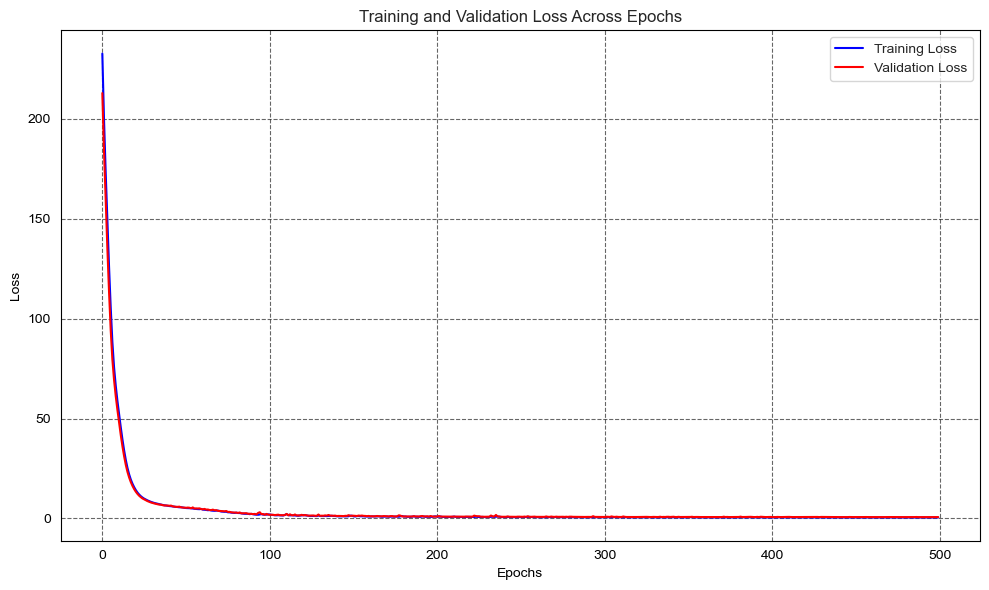

In [9]:
#Training and Validation Loss Across Epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plot_path = os.path.join(save_folder, "loss_G_REN.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()


# Strategy 2: system identification of the negative feedback of K and S

### Closed loop model of REN in negative feedback with K, loss function and optimizer

In [10]:
#-----------------------------closedloop sysid of S through RENs------------------------
#--------------------------Define model for sysid---------------------------------------------
#create the REN model for S
y_init = x0
REN_S = ContractiveREN(input_dim = input_dim, output_dim = output_dim, state_dim = n_xi, dim_nl = l)
closed_loop_REN = ClosedLoopSystem(REN_S, controller, negative=True)
closed_loop_closed_loop_1 = ClosedLoopSystem(closed_loop_REN, controller)
#--------------------------Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()

optimizer = torch.optim.Adam(REN_S.parameters(), lr=learning_rate)
optimizer.zero_grad()

### Training and validation loop

In [11]:
#--------------------------5. Training---------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REN_S.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs

for epoch in range(epochs):
    # ---------------- TRAINING ---------------- #
    closed_loop_REN.train()
    loss_epoch = 0.0  # Accumulate training loss

    for _, u_batch, y_batch in train_loader:
        u_batch, y_batch = u_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        _, y_hat_train_S = closed_loop_REN(x0, u_batch, output_noise = None)

        loss_batch = MSE(y_hat_train_S, y_batch)

        loss_batch.backward()

        optimizer.step()

        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    closed_loop_REN.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for _, u_batch, y_batch in val_loader:
            u_batch, y_batch = u_batch.to(device), y_batch.to(device)

            _, y_hat_val = closed_loop_REN(x0, u_batch, output_noise = None)

            loss_batch_val = MSE(y_hat_val, y_batch)

            loss_val_epoch += loss_batch_val.item()

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")

# Save the trained model
filename = os.path.join(save_folder, 'closed_loop_REN_trained_model' + '.pt')
torch.save(closed_loop_REN.state_dict(), filename)
filename = os.path.join(save_folder, 'REN_S_trained_model' + '.pt')
torch.save(REN_S.state_dict(), filename)

Epoch: 1 	||	 Training Loss: 113.749498 	||	 Validation Loss: 102.761664
Epoch: 2 	||	 Training Loss: 94.256203 	||	 Validation Loss: 86.999544
Epoch: 3 	||	 Training Loss: 80.970804 	||	 Validation Loss: 76.118045
Epoch: 4 	||	 Training Loss: 71.359560 	||	 Validation Loss: 68.178878
Epoch: 5 	||	 Training Loss: 64.068701 	||	 Validation Loss: 61.537831
Epoch: 6 	||	 Training Loss: 57.746512 	||	 Validation Loss: 55.487566
Epoch: 7 	||	 Training Loss: 51.906106 	||	 Validation Loss: 49.740854
Epoch: 8 	||	 Training Loss: 46.454922 	||	 Validation Loss: 44.189973
Epoch: 9 	||	 Training Loss: 41.300796 	||	 Validation Loss: 39.096237
Epoch: 10 	||	 Training Loss: 36.767555 	||	 Validation Loss: 34.612215
Epoch: 11 	||	 Training Loss: 32.903454 	||	 Validation Loss: 31.024005
Epoch: 12 	||	 Training Loss: 29.869316 	||	 Validation Loss: 28.381177
Epoch: 13 	||	 Training Loss: 27.565448 	||	 Validation Loss: 26.300234
Epoch: 14 	||	 Training Loss: 25.627710 	||	 Validation Loss: 24.403724

### Plots: loss for the negative feedback of S and K

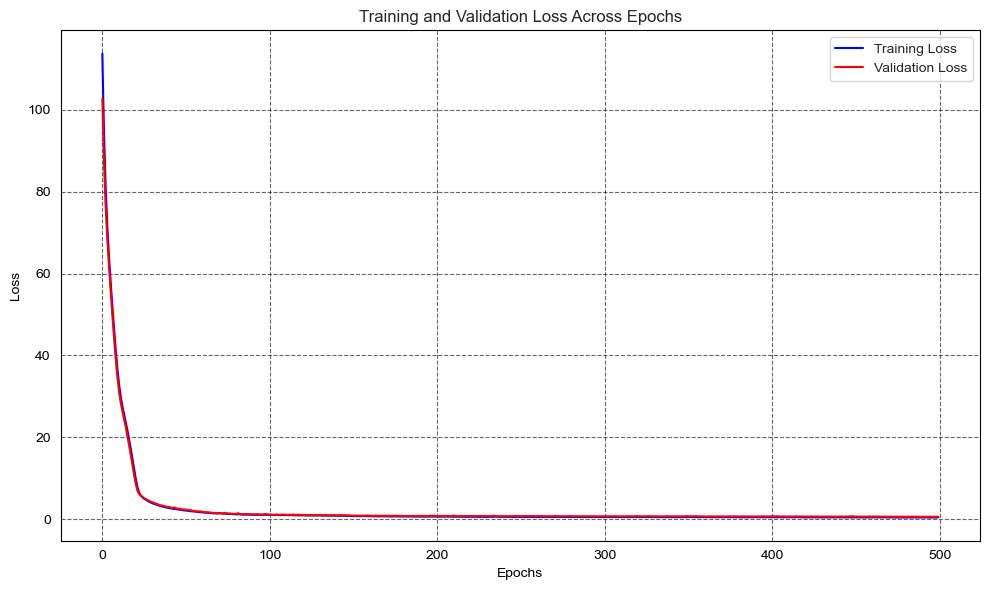

In [12]:
#Training and Validation Loss Across Epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Strategy 3: System identification of S using reference inputs

In [13]:
#-----------------------------closedloop sysid of S through RENs------------------------
#--------------------------Define model for sysid---------------------------------------------
#create the REN model for S

y_init = x0
REN_S_2 = ContractiveREN(input_dim=input_dim, output_dim=output_dim, state_dim=n_xi, dim_nl=l)
closed_loop_REN_2 = ClosedLoopSystem(REN_S_2, controller, negative=True)
#create the closed loop with the identified model which is itself a closed loop
closed_loop_closed_loop_2 = ClosedLoopSystem(closed_loop_REN_2, controller)

#--------------------------Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()
optimizer = torch.optim.Adam(REN_S_2.parameters(), lr=learning_rate)
optimizer.zero_grad()

### Training and validation loop

In [14]:
#--------------------------5. Training---------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REN_S_2.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs):
    # ---------------- TRAINING ---------------- #
    REN_S_2.train()
    loss_epoch = 0.0  # Accumulate training loss

    for u_ext_batch, _, y_batch in train_loader:
        u_ext_batch, y_batch = u_ext_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_hat_train_G = REN_S_2(x0, u_ext_batch)
        loss_batch = MSE(y_hat_train_G, y_batch)


        loss_batch.backward()
        optimizer.step()

        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    REN_S_2.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for u_ext_batch, _, y_batch in val_loader:
            u_ext_batch, y_batch = u_ext_batch.to(device), y_batch.to(device)
            
            y_hat_val = REN_S_2(x0, u_ext_batch)
            loss_batch_val = MSE(y_hat_val, y_batch)

            loss_val_epoch += loss_batch_val.item()

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")

# Save the trained model
filename = os.path.join(save_folder, 'closed_loop_REN_2_trained_model' + '.pt')
torch.save(closed_loop_REN_2.state_dict(), filename)
filename = os.path.join(save_folder, 'REN_S_2_trained_model' + '.pt')
torch.save(REN_S_2.state_dict(), filename)

Epoch: 1 	||	 Training Loss: 126.962965 	||	 Validation Loss: 118.176563
Epoch: 2 	||	 Training Loss: 117.252587 	||	 Validation Loss: 109.821251
Epoch: 3 	||	 Training Loss: 109.330223 	||	 Validation Loss: 102.846582
Epoch: 4 	||	 Training Loss: 102.590335 	||	 Validation Loss: 96.697566
Epoch: 5 	||	 Training Loss: 96.495402 	||	 Validation Loss: 91.131383
Epoch: 6 	||	 Training Loss: 90.868489 	||	 Validation Loss: 85.890138
Epoch: 7 	||	 Training Loss: 85.406893 	||	 Validation Loss: 80.772758
Epoch: 8 	||	 Training Loss: 79.987785 	||	 Validation Loss: 75.489729
Epoch: 9 	||	 Training Loss: 74.285363 	||	 Validation Loss: 69.890715
Epoch: 10 	||	 Training Loss: 68.075579 	||	 Validation Loss: 63.797842
Epoch: 11 	||	 Training Loss: 61.338903 	||	 Validation Loss: 57.397140
Epoch: 12 	||	 Training Loss: 54.560444 	||	 Validation Loss: 51.115657
Epoch: 13 	||	 Training Loss: 47.797304 	||	 Validation Loss: 44.136694
Epoch: 14 	||	 Training Loss: 37.127347 	||	 Validation Loss: 28.1

### Plots: loss strategy 3

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/loss_3.png


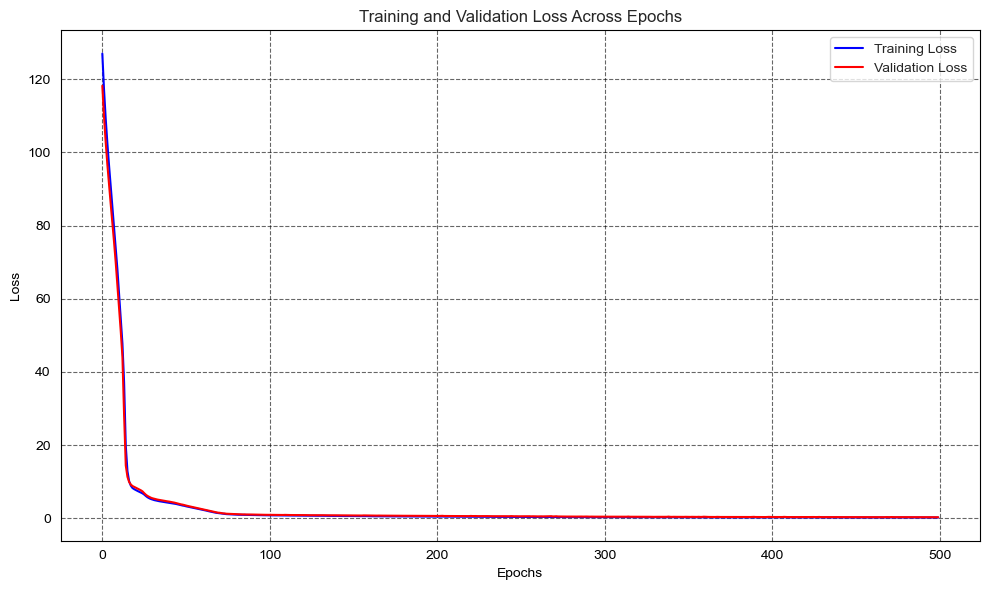

In [15]:
#Training and Validation Loss Across Epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plot_path = os.path.join(save_folder, "loss_3.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()

# PLOTS

In [16]:
#-------------------------------test dataset for plotting: 100 trajectories------------------------------
test_indices = test_dataset.indices  # Get test sample indices
#external reference
u_ref_test = test_dataset.dataset.external_input_data[test_indices]
#control input
u_test = test_dataset.dataset.plant_input_data[test_indices]
#closed loop output
y_CL_test = test_dataset.dataset.output_data[test_indices]
#output noise
output_noise_test = test_dataset.dataset.output_noise[test_indices]
#open loop output
y_OL_test = plant(x0=x0, u_ext=u_ref_test, output_noise=None)

u_ref_test_np = u_ref_test.detach().numpy()
u_test_np = u_test.detach().numpy()
y_CL_test_np = y_CL_test.detach().numpy()
output_noise_test_np = output_noise_test.detach().numpy()
y_OL_test_np = y_OL_test.detach().numpy()


# ---------------- TESTING ---------------- #
#open loop
REN_G.eval()
y_OL_1 = REN_G(x0, u_ref_test)
y_OL_1 = y_OL_1.detach().numpy()
#closed loop
closed_loop_G.eval()
_, y_CL_1 = closed_loop_G(x0=x0, u_ext=u_ref_test, output_noise = output_noise_test)
y_CL_1 = y_CL_1.detach().numpy()

#open loop
closed_loop_REN.eval()
_, y_OL_2 = closed_loop_REN(x0, u_ref_test, output_noise = None)
y_OL_2 = y_OL_2.detach().numpy()

#closed loop
closed_loop_closed_loop_1.eval()
_, y_CL_2 = closed_loop_closed_loop_1(x0, u_ref_test, output_noise = output_noise_test)
y_CL_2 = y_CL_2.detach().numpy()

#open loop
closed_loop_REN_2.eval()
_, y_OL_3 = closed_loop_REN_2(x0, u_ref_test, output_noise=None)
y_OL_3 = y_OL_3.detach().numpy()
#closed loop
closed_loop_closed_loop_2.eval()
_, y_CL_3 = closed_loop_closed_loop_2(x0=x0, u_ext=u_ref_test, output_noise=output_noise_test)
y_CL_3 = y_CL_3.detach().numpy()

### Plots: 2D open loop trajectories of the real system on external references from training data

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/2D_OL_true.png


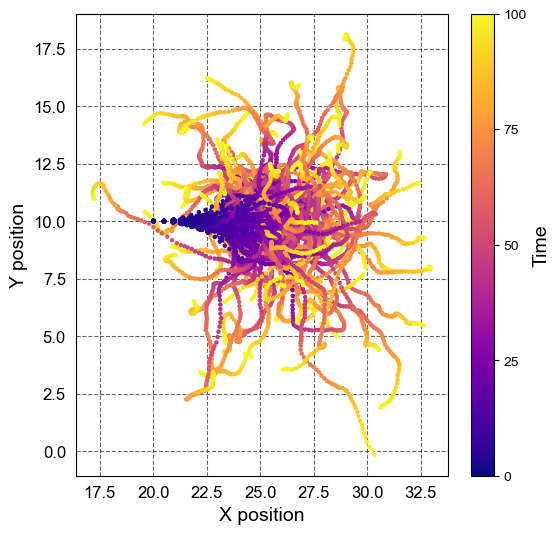

In [17]:
# Extract positions of both robots
robot1_x = y_OL_test_np[:, :, 0]  # First robot, x-position (real plant)
robot1_y = y_OL_test_np[:, :, 1]  # First robot, y-position (real plant)

# Create figure
plt.figure(figsize=(6, 6))

# Plot each batch for real plant with a color gradient
scatter1 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot1_x[i])
    colors = np.linspace(0, 100, num_points)  # Scale colors from 0 to 100
    scatter1 = plt.scatter(robot1_x[i], robot1_y[i], c=colors, cmap="plasma", s=5)  # Real plant trajectories

# Formatting
plt.xlabel("X position", fontsize=14)  # Increase font size for x-label
plt.ylabel("Y position", fontsize=14)  # Increase font size for y-label
plt.grid(True)


# Adjust tick label size
plt.xticks(fontsize=12)  # Increase font size for x-axis ticks
plt.yticks(fontsize=12)  # Increase font size for y-axis ticks

# Add colorbars for both datasets
cbar1 = plt.colorbar(scatter1)
cbar1.set_label("Time", fontsize=14)  # Increase font size for colorbar label
cbar1.set_ticks(np.linspace(0, 100, 5))  # Set ticks from 0 to 100

# Save the plot
plot_path = os.path.join(save_folder, "2D_OL_true.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()

### Plots: 2D closed loop trajectories on test dataset

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/2D_CL_true.png


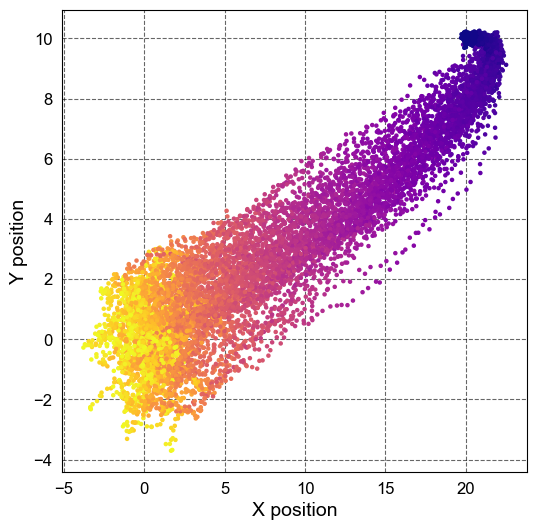

In [18]:
# Extract positions of both robots
robot1_x = y_CL_test_np[:, :, 0]  # First robot, x-position (real plant)
robot1_y = y_CL_test_np[:, :, 1]  # First robot, y-position (real plant)

# Create figure
plt.figure(figsize=(6, 6))

# Plot each batch for real plant with a color gradient
scatter1 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot1_x[i])
    colors = np.linspace(0, 100, num_points)  # Scale colors from 0 to 100
    scatter1 = plt.scatter(robot1_x[i], robot1_y[i], c=colors, cmap="plasma", s=5)  # Real plant trajectories

# Formatting
plt.xlabel("X position", fontsize=14)  # Increase font size for x-label
plt.ylabel("Y position", fontsize=14)  # Increase font size for y-label
plt.grid(True)

# Adjust tick label size

# Set the axis limits


# Adjust tick label size
plt.xticks(fontsize=12)  # Increase font size for x-axis ticks
plt.yticks(fontsize=12)  # Increase font size for y-axis ticks

# # Add colorbars for both datasets
# cbar1 = plt.colorbar(scatter1)
# cbar1.set_label("Time", fontsize=14)  # Increase font size for colorbar label
# cbar1.set_ticks(np.linspace(0, 100, 5))  # Set ticks from 0 to 100

# Save the plot
plot_path = os.path.join(save_folder, "2D_CL_true.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()



## Comparison between approaches

### Plots: comparison of the open loop simulations of the real an identified models with and without K

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/comparison_OL.png


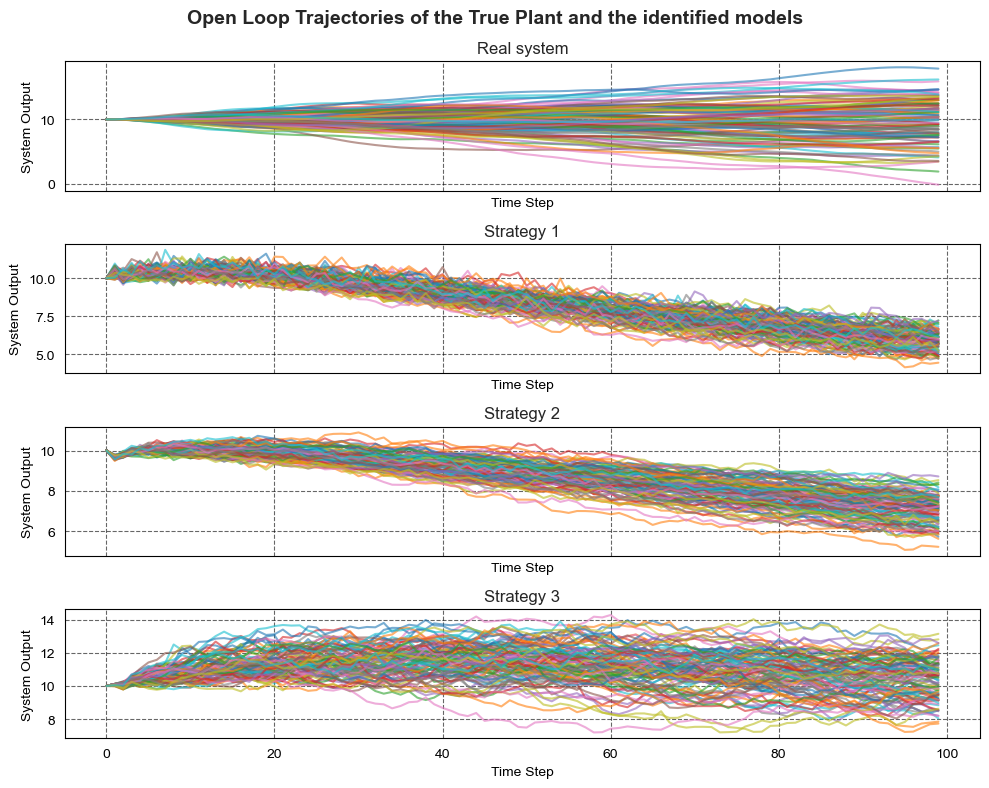

In [19]:
#-------------------------plot open loop simulation of the real plant and the identified model S in closed loop with K----------------------------------------------------

# Create a figure with three subplots
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# Plot Plant Outputs
axes[0].plot(y_OL_test[:, :, 1].T, alpha=0.6)
axes[0].set_title("Real system")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("System Output")
axes[0].grid(True)

# Plot Plant Outputs
axes[1].plot(y_OL_1[:, :, 1].T, alpha=0.6)
axes[1].set_title("Strategy 1")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("System Output")
axes[1].grid(True)

# Plot Plant Outputs
axes[2].plot(y_OL_2[:, :, 1].T, alpha=0.6)
axes[2].set_title("Strategy 2")
axes[2].set_xlabel("Time Step")
axes[2].set_ylabel("System Output")
axes[2].grid(True)

# Plot Plant Outputs
axes[3].plot(y_OL_3[:, :, 1].T, alpha=0.6)
axes[3].set_title("Strategy 3")
axes[3].set_xlabel("Time Step")
axes[3].set_ylabel("System Output")
axes[3].grid(True)

fig.suptitle("Open Loop Trajectories of the True Plant and the identified models", fontsize=14, fontweight="bold")
plt.tight_layout()
plot_path = os.path.join(save_folder, "comparison_OL.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()

### Shaded plot comparison of the open loop trajectories

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/color_comparison_OL.png


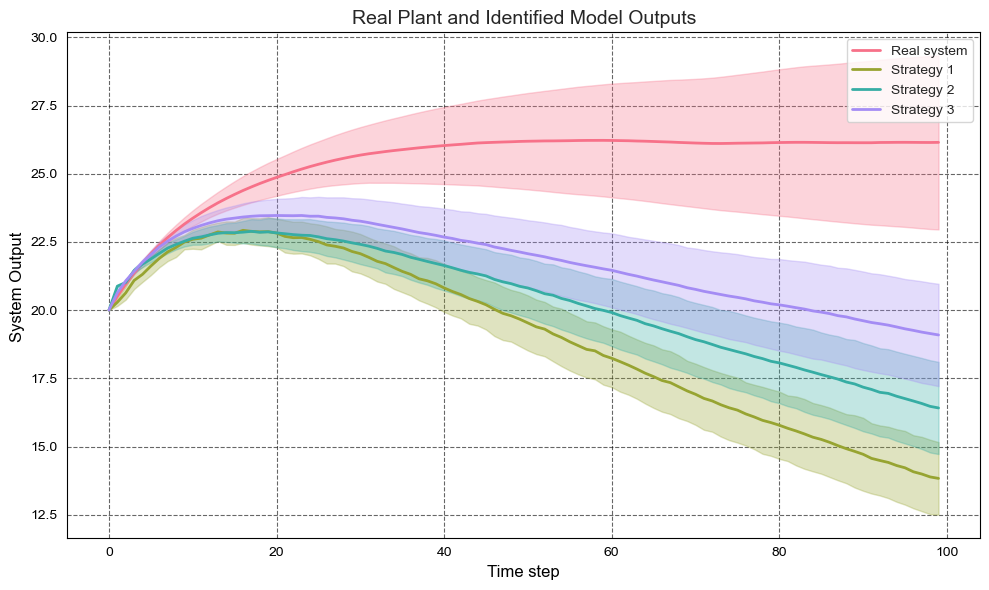

In [20]:
clrs = sns.color_palette("husl", 4)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot for y_CL (Real Plant Outputs)
mean_OL = np.mean(y_OL_test_np, axis=0)  # Mean trajectory
std_OL = np.std(y_OL_test_np, axis=0)    # Standard deviation
epochs = list(range(horizon))

ax.plot(epochs, mean_OL[:, 0], label="Real system", c=clrs[0], lw=2)
ax.fill_between(epochs, mean_OL[:, 0] - std_OL[:, 0], mean_OL[:, 0] + std_OL[:, 0],
                color=clrs[0], alpha=0.3)

# Plot for y_CL_G (Identified Model Outputs)
mean_OL_G = np.mean(y_OL_1, axis=0)  # Mean trajectory for identified model
std_OL_G = np.std(y_OL_1, axis=0)    # Standard deviation for identified model

ax.plot(epochs, mean_OL_G[:, 0], label="Strategy 1", c=clrs[1], lw=2)
ax.fill_between(epochs, mean_OL_G[:, 0] - std_OL_G[:, 0], mean_OL_G[:, 0] + std_OL_G[:, 0],
                color=clrs[1], alpha=0.3)

# Plot for y_CL_2 (Identified Model Outputs)
mean_OL_2 = np.mean(y_OL_2, axis=0)  # Mean trajectory for identified model
std_OL_2 = np.std(y_OL_2, axis=0)    # Standard deviation for identified model

ax.plot(epochs, mean_OL_2[:, 0], label="Strategy 2", c=clrs[2], lw=2)
ax.fill_between(epochs, mean_OL_2[:, 0] - std_OL_2[:, 0], mean_OL_2[:, 0] + std_OL_2[:, 0],
                color=clrs[2], alpha=0.3)

# Plot for y_CL_3 (Identified Model Outputs)
mean_OL_3 = np.mean(y_OL_3, axis=0)  # Mean trajectory for identified model
std_OL_3 = np.std(y_OL_3, axis=0)    # Standard deviation for identified model

ax.plot(epochs, mean_OL_3[:, 0], label="Strategy 3", c=clrs[3], lw=2)
ax.fill_between(epochs, mean_OL_3[:, 0] - std_OL_3[:, 0], mean_OL_3[:, 0] + std_OL_3[:, 0],
                color=clrs[3], alpha=0.3)

# Add labels, title, and legend
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("System Output ", fontsize=12)
ax.set_title("Real Plant and Identified Model Outputs", fontsize=14)
ax.legend(loc='upper right')

# Set the y-axis to logarithmic scale
#ax.set_yscale('log')

# Display the grid and plot
ax.grid(True, which="both", ls="--")
plt.tight_layout()
plot_path = os.path.join(save_folder, "color_comparison_OL.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()

### Plots: comparison of the closed loop simulations of the real an identified models with and without K

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/comparison_CL.png


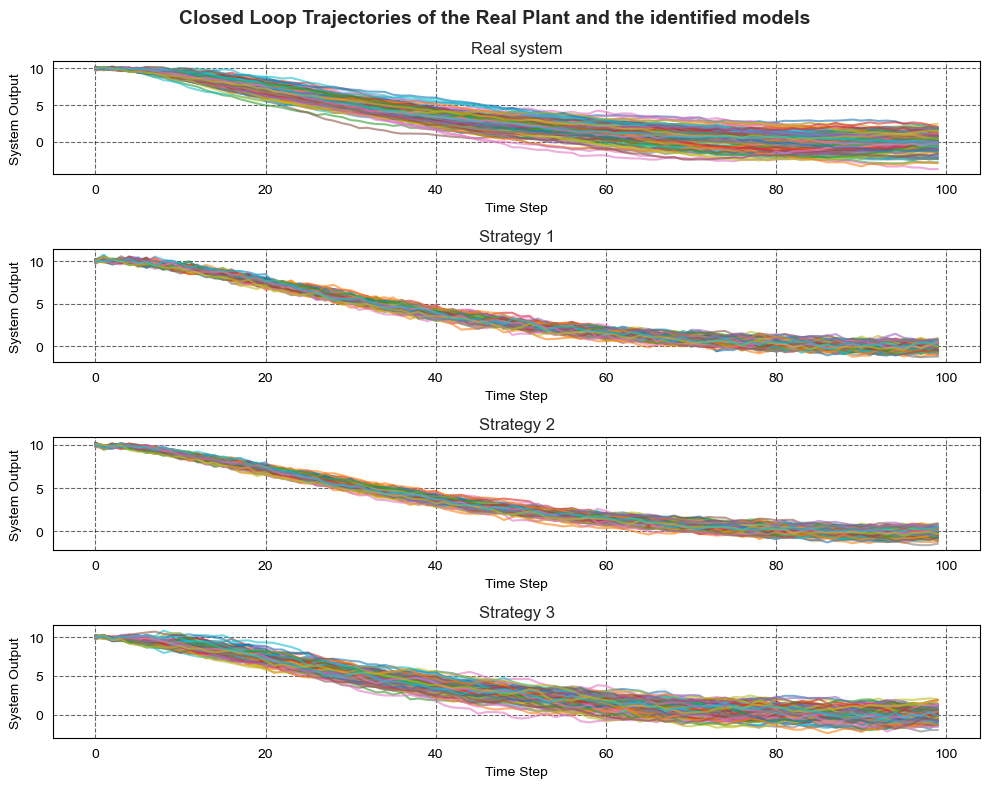

In [21]:

#-------------------------plot closed loop simulation of the real plant and the identified model G----------------------------------------------------
# Create a figure with three subplots
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=False)

# Plot Plant Inputs
axes[0].plot(y_CL_test[:, :, 1].T, alpha=0.6)
axes[0].set_title("Real system")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("System Output")
axes[0].grid(True)

# Plot Plant Outputs
axes[1].plot(y_CL_1[:, :, 1].T, alpha=0.6)
axes[1].set_title("Strategy 1")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("System Output")
axes[1].grid(True)

# Plot Plant Outputs
axes[2].plot(y_CL_2[:, :, 1].T, alpha=0.6)
axes[2].set_title("Strategy 2")
axes[2].set_xlabel("Time Step")
axes[2].set_ylabel("System Output")
axes[2].grid(True)

# Plot Plant Outputs
axes[3].plot(y_CL_3[:, :, 1].T, alpha=0.6)
axes[3].set_title("Strategy 3")
axes[3].set_xlabel("Time Step")
axes[3].set_ylabel("System Output")
axes[3].grid(True)

fig.suptitle("Closed Loop Trajectories of the Real Plant and the identified models", fontsize=14, fontweight="bold")
plt.tight_layout()
plot_path = os.path.join(save_folder, "comparison_CL.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()

### Shaded plot: comparison of closed loop trajectories

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/color_comparison_CL.png


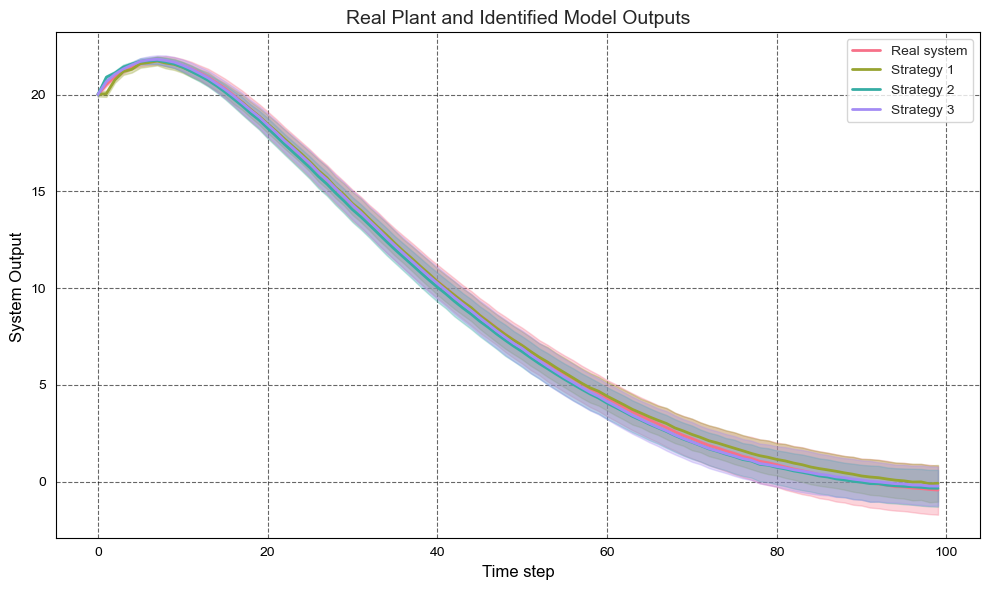

In [22]:
clrs = sns.color_palette("husl", 4)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot for y_CL (Real Plant Outputs)
mean_CL = np.mean(y_CL_test_np, axis=0)  # Mean trajectory
std_CL = np.std(y_CL_test_np, axis=0)    # Standard deviation
epochs = list(range(horizon))

ax.plot(epochs, mean_CL[:, 0], label="Real system", c=clrs[0], lw=2)
ax.fill_between(epochs, mean_CL[:, 0] - std_CL[:, 0], mean_CL[:, 0] + std_CL[:, 0],
                color=clrs[0], alpha=0.3)

# Plot for y_CL_G (Identified Model Outputs)
mean_CL_G = np.mean(y_CL_1, axis=0)  # Mean trajectory for identified model
std_CL_G = np.std(y_CL_1, axis=0)    # Standard deviation for identified model

ax.plot(epochs, mean_CL_G[:, 0], label="Strategy 1", c=clrs[1], lw=2)
ax.fill_between(epochs, mean_CL_G[:, 0] - std_CL_G[:, 0], mean_CL_G[:, 0] + std_CL_G[:, 0],
                color=clrs[1], alpha=0.3)

# Plot for y_CL_2 (Identified Model Outputs)
mean_CL_2 = np.mean(y_CL_2, axis=0)  # Mean trajectory for identified model
std_CL_2 = np.std(y_CL_2, axis=0)    # Standard deviation for identified model

ax.plot(epochs, mean_CL_2[:, 0], label="Strategy 2", c=clrs[2], lw=2)
ax.fill_between(epochs, mean_CL_2[:, 0] - std_CL_2[:, 0], mean_CL_2[:, 0] + std_CL_2[:, 0],
                color=clrs[2], alpha=0.3)

# Plot for y_CL_3 (Identified Model Outputs)
mean_CL_3 = np.mean(y_CL_3, axis=0)  # Mean trajectory for identified model
std_CL_3 = np.std(y_CL_3, axis=0)    # Standard deviation for identified model

ax.plot(epochs, mean_CL_3[:, 0], label="Strategy 3", c=clrs[3], lw=2)
ax.fill_between(epochs, mean_CL_3[:, 0] - std_CL_3[:, 0], mean_CL_3[:, 0] + std_CL_3[:, 0],
                color=clrs[3], alpha=0.3)

# Add labels, title, and legend
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("System Output ", fontsize=12)
ax.set_title("Real Plant and Identified Model Outputs", fontsize=14)
ax.legend(loc='upper right')

# Set the y-axis to logarithmic scale
#ax.set_yscale('log')

# Display the grid and plot
ax.grid(True, which="both", ls="--")
plt.tight_layout()
plot_path = os.path.join(save_folder, "color_comparison_CL.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()


### Plot: 2D closed loop of strategy 1

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/2D_CL_strat_1.png


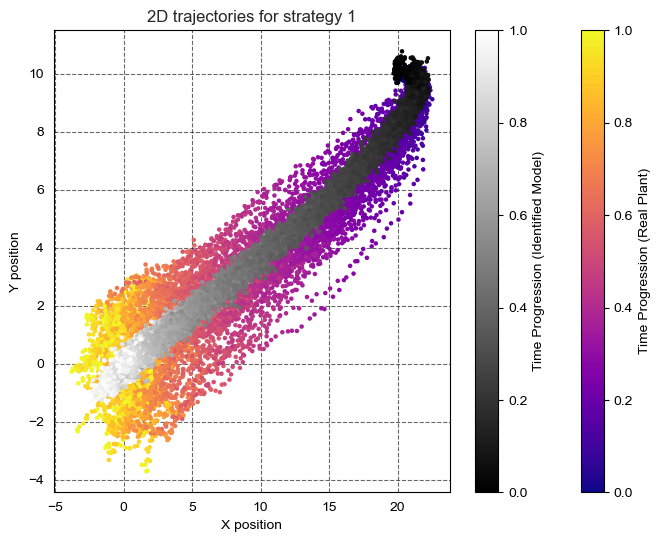

In [23]:
# Extract positions of both robots
robot1_x = y_CL_test_np[:, :, 0]  # First robot, x-position (real plant)
robot1_y = y_CL_test_np[:, :, 1]  # First robot, y-position (real plant)
robot2_x = y_CL_1[:, :, 0]  # First robot, x-position (identified model)
robot2_y = y_CL_1[:, :, 1]  # First robot, y-position (identified model)

# Create figure
plt.figure(figsize=(8, 6))

# Plot each batch for real plant with a color gradient
scatter1 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot1_x[i])
    colors = np.linspace(0, 1, num_points)  # Create a gradient scale
    scatter1 = plt.scatter(robot1_x[i], robot1_y[i], c=colors, cmap="plasma", s=5)  # Real plant trajectories

# Plot each batch for identified model with a different color gradient
scatter2 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot2_x[i])
    colors = np.linspace(0, 1, num_points)  # Create a gradient scale
    scatter2 = plt.scatter(robot2_x[i], robot2_y[i], c=colors, cmap="gray", s=5)  # Identified model trajectories

# Formatting
plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("2D trajectories for strategy 1")
plt.grid(True)

# Add colorbars for both datasets
cbar1 = plt.colorbar(scatter1, label="Time Progression (Real Plant)")
cbar2 = plt.colorbar(scatter2, label="Time Progression (Identified Model)")

# Save the plot
plot_path = os.path.join(save_folder, "2D_CL_strat_1.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()



### Plot: 2D closed loop of strategy 2

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/2D_CL_strat_2.png


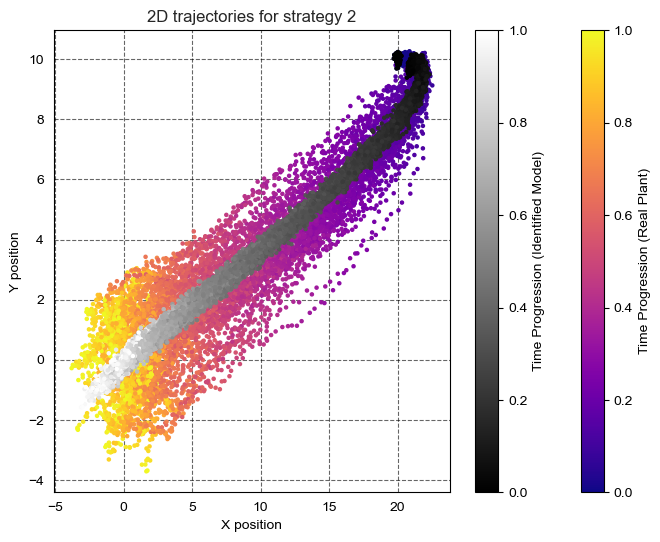

In [24]:
# Extract positions of both robots
robot1_x = y_CL_test_np[:, :, 0]  # First robot, x-position (real plant)
robot1_y = y_CL_test_np[:, :, 1]  # First robot, y-position (real plant)
robot2_x = y_CL_2[:, :, 0]  # First robot, x-position (identified model)
robot2_y = y_CL_2[:, :, 1]  # First robot, y-position (identified model)

# Create figure
plt.figure(figsize=(8, 6))


# Plot each batch for real plant with a color gradient
scatter1 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot1_x[i])
    colors = np.linspace(0, 1, num_points)  # Create a gradient scale
    scatter1 = plt.scatter(robot1_x[i], robot1_y[i], c=colors, cmap="plasma", s=5)  # Real plant trajectories

# Plot each batch for identified model with a different color gradient
scatter2 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot2_x[i])
    colors = np.linspace(0, 1, num_points)  # Create a gradient scale
    scatter2 = plt.scatter(robot2_x[i], robot2_y[i], c=colors, cmap="gray", s=5)  # Identified model trajectories

# Formatting
plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("2D trajectories for strategy 2")
plt.grid(True)

# Add colorbars for both datasets
cbar1 = plt.colorbar(scatter1, label="Time Progression (Real Plant)")
cbar2 = plt.colorbar(scatter2, label="Time Progression (Identified Model)")

# Save the plot
plot_path = os.path.join(save_folder, "2D_CL_strat_2.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()

### Plot: 2D closed loop of strategy 3

Plot saved at: /Users/laurameroi/Desktop/Nonlinear_system_identification/saved_results_robot/03_27_08_48_22_std_ini10_std_out0.1_x0tensor([20., 10., 10.,  0.])_epochs500_seed1_n_xi8/2D_CL_strat_3.png


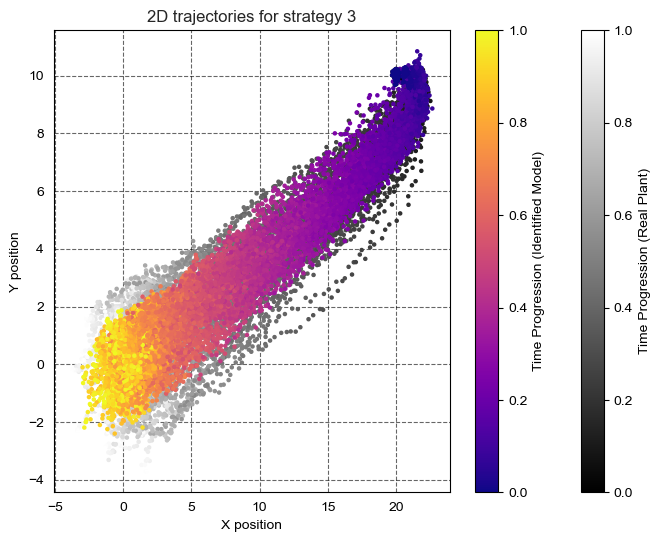

In [25]:
# Extract positions of both robots
robot1_x = y_CL_test_np[:, :, 0]  # First robot, x-position (real plant)
robot1_y = y_CL_test_np[:, :, 1]  # First robot, y-position (real plant)
robot2_x = y_CL_3[:, :, 0]  # First robot, x-position (identified model)
robot2_y = y_CL_3[:, :, 1]  # First robot, y-position (identified model)

# Create figure
plt.figure(figsize=(8, 6))

# Plot each batch for real plant with a color gradient
scatter1 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot1_x[i])
    colors = np.linspace(0, 1, num_points)  # Create a gradient scale
    scatter1 = plt.scatter(robot1_x[i], robot1_y[i], c=colors, cmap="gray", s=5)  # Real plant trajectories

# Plot each batch for identified model with a different color gradient
scatter2 = None
for i in range(test_size):  # Iterate over batches
    num_points = len(robot2_x[i])
    colors = np.linspace(0, 1, num_points)  # Create a gradient scale
    scatter2 = plt.scatter(robot2_x[i], robot2_y[i], c=colors, cmap="plasma", s=5)  # Identified model trajectories

# Formatting
plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("2D trajectories for strategy 3")
plt.grid(True)

# Add colorbars for both datasets
cbar1 = plt.colorbar(scatter1, label="Time Progression (Real Plant)")
cbar2 = plt.colorbar(scatter2, label="Time Progression (Identified Model)")

# Save the plot
plot_path = os.path.join(save_folder, "2D_CL_strat_3.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Plot saved at: {plot_path}")
plt.show()

### Function to compute confidence intervals and R-squared


In [26]:
def get_conf_interval(array, confidence=95, n_digits=6, format='plus_minus'):
    array = np.array(array).flatten()
    num_samples = len(array)
    sample_mean = np.mean(array)
    sample_var = ((array - sample_mean)**2).sum() / (num_samples - 1)
    sample_std = sample_var**0.5

    if confidence == 95:
        z = 1.96  # for 95% confidence interval
    elif confidence == 99:
        z = 2.576  # for 99% confidence interval
    else:
        raise NotImplementedError("Only 95 and 99 confidence intervals are implemented.")

    if format == 'plus_minus':
        print('Confidence interval: %f +/- %f' % (
            np.around(sample_mean, decimals=n_digits),
            np.around(z * sample_std / num_samples**0.5, decimals=n_digits)
        ))
    else:
        l_bound = sample_mean - z * sample_std / np.sqrt(num_samples)
        u_bound = sample_mean + z * sample_std / np.sqrt(num_samples)
        l_bound = np.around(l_bound, decimals=n_digits)
        u_bound = np.around(u_bound, decimals=n_digits)
        print('Confidence interval: [%f, %f]' % (l_bound, u_bound))

def compute_r_squared(y_true, y_pred):
    # Compute the mean of the true values along test_size axis (to get a baseline model)
    y_mean = np.mean(y_true, keepdims=True)  # Shape (1, horizon, output_dim)

    # Compute the sum of squared residuals
    ss_res = np.sum((y_true - y_pred) ** 2)

    # Compute the total sum of squares
    ss_tot = np.sum((y_true - y_mean) ** 2)

    # Compute R²
    r_squared = 1 - (ss_res / ss_tot)
    return r_squared

### Confidence interval for MSE of the open loop and closed loop trajectories over 50 different test datasets obtained by setting 50 different seeds

In [27]:
# Array to store the mean MSEs for the open loop for different seeds
mse_values_1_OL = []
mse_values_2_OL = []
mse_values_3_OL = []
# Array to store the mean MSEs for the closed loop for different seeds
mse_values_1_CL = []
mse_values_2_CL = []
mse_values_3_CL = []


num_seeds = 50  # Number of seeds to use


for seed_i in range(num_seeds):
    test_dataset = SystemIdentificationDataset(num_signals = test_size, horizon = horizon, input_dim = input_dim, state_dim = state_dim, output_dim = output_dim, closed_loop = closed_loop, input_noise_std = input_noise_std, output_noise_std = output_noise_std, fixed_x0 = x0, seed = seed_i)

    #-------------------------------test data------------------------------
    # Extract only the test subset of the dataset
    u_ref_test = test_dataset.external_input_data
    u_K_test = test_dataset.plant_input_data
    y_CL_test = test_dataset.output_data
    output_noise_test = test_dataset.output_noise

    #---------------Real plant Open loop trajectories on references from test datset (r, y_OL) -----------------------
    y_OL_test = plant(x0=x0, u_ext=u_ref_test, output_noise=output_noise_test)

    u_ref_test_np = u_ref_test.detach().numpy()
    u_K_test_np = u_K_test.detach().numpy()
    y_CL_test_np = y_CL_test.detach().numpy()
    y_OL_test_np = y_OL_test.detach().numpy()
    output_noise_test_np = output_noise_test.detach().numpy()

    REN_G.eval()
    y_OL_1 = REN_G(x0, u_ref_test)
    y_OL_1 = y_OL_1.detach().numpy()
    #closed loop
    closed_loop_G.eval()
    _, y_CL_1 = closed_loop_G(x0=x0, u_ext=u_ref_test, output_noise = output_noise_test)
    y_CL_1 = y_CL_1.detach().numpy()

    #open loop
    closed_loop_REN.eval()
    _, y_OL_2 = closed_loop_REN(x0, u_ref_test, output_noise = None)
    y_OL_2 = y_OL_2.detach().numpy()

    #closed loop
    closed_loop_closed_loop_1.eval()
    _, y_CL_2 = closed_loop_closed_loop_1(x0, u_ref_test, output_noise = output_noise_test)
    y_CL_2 = y_CL_2.detach().numpy()

    #open loop
    closed_loop_REN_2.eval()
    _, y_OL_3 = closed_loop_REN_2(x0, u_ref_test, output_noise=None)
    y_OL_3 = y_OL_3.detach().numpy()
    #closed loop
    closed_loop_closed_loop_2.eval()
    _, y_CL_3 = closed_loop_closed_loop_2(x0=x0, u_ext=u_ref_test, output_noise=output_noise_test)
    y_CL_3 = y_CL_3.detach().numpy()


    # Compute MSE for each model
    mse_loss_G_OL = np.mean((y_OL_test_np - y_OL_1) ** 2)
    mse_loss_G_1_OL = np.mean((y_OL_test_np - y_OL_2) ** 2)
    mse_loss_G_2_OL = np.mean((y_OL_test_np - y_OL_3) ** 2)

    # Compute MSE for each model
    mse_loss_G_CL = np.mean((y_CL_test_np - y_CL_1) ** 2)
    mse_loss_G_1_CL = np.mean((y_CL_test_np - y_CL_2) ** 2)
    mse_loss_G_2_CL = np.mean((y_CL_test_np - y_CL_3) ** 2)

    # Store MSE in the array
    mse_values_1_OL.append(mse_loss_G_OL)
    mse_values_2_OL.append(mse_loss_G_1_OL)
    mse_values_3_OL.append(mse_loss_G_2_OL)

    # Store MSE in the array
    mse_values_1_CL.append(mse_loss_G_CL)
    mse_values_2_CL.append(mse_loss_G_1_CL)
    mse_values_3_CL.append(mse_loss_G_2_CL)

# Convert list to NumPy array
mse_values_1_np_OL = np.array(mse_values_1_OL)
mse_values_2_np_OL = np.array(mse_values_2_OL)
mse_values_3_np_OL = np.array(mse_values_3_OL)

# Convert list to NumPy array
mse_values_1_np_CL = np.array(mse_values_1_CL)
mse_values_2_np_CL = np.array(mse_values_2_CL)
mse_values_3_np_CL = np.array(mse_values_3_CL)


# Compute confidence interval for open loop
print('MSE confidence interval for open loop')
get_conf_interval(mse_values_1_np_OL)
get_conf_interval(mse_values_2_np_OL)
get_conf_interval(mse_values_3_np_OL)
# Compute confidence interval for closed loop
print('MSE confidence interval for closed loop')
get_conf_interval(mse_values_1_np_CL)
get_conf_interval(mse_values_2_np_CL)
get_conf_interval(mse_values_3_np_CL)

confidence_interval_path_MSE = os.path.join(save_folder, "confidence_intervals_MSE.txt")
# Open the file in write mode
# with open(confidence_interval_path_MSE, "w") as f:
#     # Redirect print statements to the file
#     f.write('MSE confidence interval for open loop\n')
#     f.write(f"Confidence interval for mse_values_1_np_OL: {get_conf_interval(mse_values_1_np_OL)}\n")
#     f.write(f"Confidence interval for mse_values_2_np_OL: {get_conf_interval(mse_values_2_np_OL)}\n")
#     f.write(f"Confidence interval for mse_values_3_np_OL: {get_conf_interval(mse_values_3_np_OL)}\n")
#
#     f.write('MSE confidence interval for closed loop\n')
#     f.write(f"Confidence interval for mse_values_1_np_CL: {get_conf_interval(mse_values_1_np_CL)}\n")
#     f.write(f"Confidence interval for mse_values_2_np_CL: {get_conf_interval(mse_values_2_np_CL)}\n")
#     f.write(f"Confidence interval for mse_values_3_np_CL: {get_conf_interval(mse_values_3_np_CL)}\n")

MSE confidence interval for open loop
Confidence interval: 17.684681 +/- 0.099156
Confidence interval: 11.546822 +/- 0.067444
Confidence interval: 6.735110 +/- 0.058610
MSE confidence interval for closed loop
Confidence interval: 0.479996 +/- 0.009034
Confidence interval: 0.391561 +/- 0.008633
Confidence interval: 0.239761 +/- 0.004922


### Confidence interval for R-squared of the open loop and closed loop trajectories over 50 different test datasets obtained by setting 50 different seeds

In [28]:
# Array to store the mean R-squared for the open loop for different seeds
r_squared_values_1_OL = []
r_squared_values_2_OL = []
r_squared_values_3_OL = []
# Array to store the mean R-squared for the closed loop for different seeds
r_squared_values_1_CL = []
r_squared_values_2_CL = []
r_squared_values_3_CL = []


num_seeds = 50  # Number of seeds to use


for seed_i in range(num_seeds):
    test_dataset = SystemIdentificationDataset(num_signals = test_size, horizon = horizon, input_dim = input_dim, state_dim = state_dim, output_dim = output_dim, closed_loop = closed_loop, input_noise_std = input_noise_std, output_noise_std = output_noise_std, fixed_x0 = x0, seed = seed_i)

    #-------------------------------test data------------------------------
    # Extract only the test subset of the dataset
    u_ref_test = test_dataset.external_input_data
    u_K_test = test_dataset.plant_input_data
    y_CL_test = test_dataset.output_data
    output_noise_test = test_dataset.output_noise

    #---------------Real plant Open loop trajectories on references from test datset (r, y_OL) -----------------------
    y_OL_test = plant(x0=x0, u_ext=u_ref_test, output_noise=output_noise_test)

    u_ref_test_np = u_ref_test.detach().numpy()
    u_K_test_np = u_K_test.detach().numpy()
    y_CL_test_np = y_CL_test.detach().numpy()
    y_OL_test_np = y_OL_test.detach().numpy()
    output_noise_test_np = output_noise_test.detach().numpy()

    REN_G.eval()
    y_OL_1 = REN_G(x0, u_ref_test)
    y_OL_1 = y_OL_1.detach().numpy()
    #closed loop
    closed_loop_G.eval()
    _, y_CL_1 = closed_loop_G(x0=x0, u_ext=u_ref_test, output_noise = output_noise_test)
    y_CL_1 = y_CL_1.detach().numpy()

    #open loop
    closed_loop_REN.eval()
    _, y_OL_2 = closed_loop_REN(x0, u_ref_test, output_noise = None)
    y_OL_2 = y_OL_2.detach().numpy()

    #closed loop
    closed_loop_closed_loop_1.eval()
    _, y_CL_2 = closed_loop_closed_loop_1(x0, u_ref_test, output_noise = output_noise_test)
    y_CL_2 = y_CL_2.detach().numpy()

    #open loop
    closed_loop_REN_2.eval()
    _, y_OL_3 = closed_loop_REN_2(x0, u_ref_test, output_noise=None)
    y_OL_3 = y_OL_3.detach().numpy()
    #closed loop
    closed_loop_closed_loop_2.eval()
    _, y_CL_3 = closed_loop_closed_loop_2(x0=x0, u_ext=u_ref_test, output_noise=output_noise_test)
    y_CL_3 = y_CL_3.detach().numpy()


    # Compute r_squared for each model
    r_squared_loss_G_OL = compute_r_squared(y_OL_test_np,y_OL_1)
    r_squared_loss_G_1_OL = compute_r_squared(y_OL_test_np,y_OL_2)
    r_squared_loss_G_2_OL = compute_r_squared(y_OL_test_np,y_OL_3)

    # Compute r_squared for each model
    r_squared_loss_G_CL = compute_r_squared(y_CL_test_np,y_CL_1)
    r_squared_loss_G_1_CL = compute_r_squared(y_CL_test_np,y_CL_2)
    r_squared_loss_G_2_CL = compute_r_squared(y_CL_test_np,y_CL_3)

    # Store r_squared in the array
    r_squared_values_1_OL.append(r_squared_loss_G_OL)
    r_squared_values_2_OL.append(r_squared_loss_G_1_OL)
    r_squared_values_3_OL.append(r_squared_loss_G_2_OL)

    # Store r_squared in the array
    r_squared_values_1_CL.append(r_squared_loss_G_CL)
    r_squared_values_2_CL.append(r_squared_loss_G_1_CL)
    r_squared_values_3_CL.append(r_squared_loss_G_2_CL)

# Convert list to NumPy array
r_squared_values_1_np_OL = np.array(r_squared_values_1_OL)
r_squared_values_2_np_OL = np.array(r_squared_values_2_OL)
r_squared_values_3_np_OL = np.array(r_squared_values_3_OL)

# Convert list to NumPy array
r_squared_values_1_np_CL = np.array(r_squared_values_1_CL)
r_squared_values_2_np_CL = np.array(r_squared_values_2_CL)
r_squared_values_3_np_CL = np.array(r_squared_values_3_CL)


# Compute confidence interval for open loop
print('R-squared confidence interval for open loop')
print('Strategy 1:')
get_conf_interval(r_squared_values_1_np_OL)
print('Strategy 2:')
get_conf_interval(r_squared_values_2_np_OL)
print('Strategy 3:')
get_conf_interval(r_squared_values_3_np_OL)
# Compute confidence interval for closed loop
print('R-squared confidence interval for closed loop')
print('Strategy 1:')
get_conf_interval(r_squared_values_1_np_CL)
print('Strategy 2:')
get_conf_interval(r_squared_values_2_np_CL)
print('Strategy 3:')
get_conf_interval(r_squared_values_3_np_CL)

confidence_interval_path_R_squared = os.path.join(save_folder, "confidence_intervals_R_squared.txt")
# Open the file in write mode
# with open(confidence_interval_path_R_squared, "w") as f:
#     # Redirect print statements to the file
#     f.write('R-squared confidence interval for open loop\n')
#     f.write(f"Confidence interval for r_squared_values_1_np_OL: {get_conf_interval(r_squared_values_1_np_OL)}\n")
#     f.write(f"Confidence interval for r_squared_values_2_np_OL: {get_conf_interval(r_squared_values_2_np_OL)}\n")
#     f.write(f"Confidence interval for r_squared_values_3_np_OL: {get_conf_interval(r_squared_values_3_np_OL)}\n")
#
#     f.write('R-squared confidence interval for closed loop\n')
#     f.write(f"Confidence interval for r_squared_values_1_np_CL: {get_conf_interval(r_squared_values_1_np_CL)}\n")
#     f.write(f"Confidence interval for r_squared_values_2_np_CL: {get_conf_interval(r_squared_values_2_np_CL)}\n")
#     f.write(f"Confidence interval for r_squared_values_3_np_CL: {get_conf_interval(r_squared_values_3_np_CL)}\n")

R-squared confidence interval for open loop
Strategy 1:
Confidence interval: 0.836756 +/- 0.000652
Strategy 2:
Confidence interval: 0.893413 +/- 0.000460
Strategy 3:
Confidence interval: 0.937836 +/- 0.000407
R-squared confidence interval for closed loop
Strategy 1:
Confidence interval: 0.990231 +/- 0.000179
Strategy 2:
Confidence interval: 0.992031 +/- 0.000172
Strategy 3:
Confidence interval: 0.995120 +/- 0.000097


In [29]:
# test_dataset = SystemIdentificationDataset(num_signals = 20, horizon = horizon, input_dim = input_dim, state_dim = state_dim, output_dim = output_dim, closed_loop = closed_loop, input_noise_std = 10, output_noise_std = output_noise_std, fixed_x0 = x0, seed = 1)
# 
# #-------------------------------test data------------------------------
# 
# y_CL_test = test_dataset.output_data
# y_CL_test_np = y_CL_test.detach().numpy()
# 
# # Extract positions of both robots
# robot1_x = y_CL_test_np[:, :, 0]  # First robot, x-position (real plant)
# robot1_y = y_CL_test_np[:, :, 1]  # First robot, y-position (real plant)
# 
# test_dataset = SystemIdentificationDataset(num_signals = 20, horizon = horizon, input_dim = input_dim, state_dim = state_dim, output_dim = output_dim, closed_loop = closed_loop, input_noise_std = 50, output_noise_std = output_noise_std, fixed_x0 = x0, seed = 1)
# 
# #-------------------------------test data------------------------------
# 
# y_CL_test = test_dataset.output_data
# y_CL_test_np = y_CL_test.detach().numpy()
# 
# # Extract positions of both robots
# robot2_x = y_CL_test_np[:, :, 0]  # First robot, x-position (real plant)
# robot2_y = y_CL_test_np[:, :, 1]  # First robot, y-position (real plant)
# 
# # Create figure with two subplots (1 row, 2 columns) that share the y-axis
# # Create figure with two subplots (1 row, 2 columns) that share the y-axis
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
# 
# # First subplot: Plot the first robot's trajectory (without colorbar)
# scatter1 = None
# for i in range(test_size):  # Iterate over batches
#     num_points = len(robot1_x[i])
#     colors = np.linspace(0, 100, num_points)  # Scale colors from 0 to 100
#     scatter1 = axes[0].scatter(robot1_x[i], robot1_y[i], c=colors, cmap="plasma", s=5)  # Real plant trajectories
# 
# # Formatting for the first subplot
# axes[0].set_xlabel("X position", fontsize=14)
# axes[0].set_ylabel("Y position", fontsize=14)
# axes[0].grid(True)
# axes[0].set_xlim(-15, 30)
# axes[0].set_ylim(-20, 25)
# axes[0].tick_params(axis='both', labelsize=12)  # Increase font size for ticks
# axes[0].set_aspect('equal', adjustable='box')  # Equal aspect ratio
# 
# # Second subplot: Plot the second robot's trajectory (without colorbar)
# scatter2 = None
# for i in range(test_size):  # Iterate over batches for the second robot's data
#     num_points = len(robot2_x[i])  # Assuming you have robot2_x and robot2_y
#     colors = np.linspace(0, 100, num_points)
#     scatter2 = axes[1].scatter(robot2_x[i], robot2_y[i], c=colors, cmap="plasma", s=5)  # Second robot trajectories
# 
# # Formatting for the second subplot
# axes[1].set_xlabel("X position", fontsize=14)
# axes[1].grid(True)
# axes[1].set_xlim(-15, 30)
# axes[1].set_ylim(-18, 21)  # Same y-limits as the first plot
# axes[1].tick_params(axis='both', labelsize=12)  # Increase font size for ticks
# axes[1].set_aspect('equal', adjustable='box')
# 
# # Add colorbar for both subplots (linked to both scatter1 and scatter2)
# # Add colorbar with proper height
# # Add colorbar with correct height
# cbar = fig.colorbar(scatter1, ax=axes, orientation='vertical', fraction=0.02, pad=0.05, aspect=30)
# 
# # Get figure dimensions
# fig_bbox = fig.get_window_extent().transformed(fig.dpi_scale_trans.inverted())  # Get figure bounding box
# fig_height = fig_bbox.height  # Get figure height
# 
# # Adjust the colorbar height to match the whole figure height
# pos = axes[0].get_position()  # Get subplot position
# cbar.ax.set_position([0.88, pos.y0 - 0.04, 0.03, pos.height + 0.11])  # Increase height
# 
# 
# cbar.set_label("Time", fontsize=14)
# cbar.set_ticks(np.linspace(0, 100, 5))
# 
# # Adjust layout to avoid overlap
# plt.tight_layout()
# 
# # Adjust space to move the colorbar outside the figure
# plt.subplots_adjust(right=0.85)  # Increase the right margin to fit the colorbar
# 
# # Save the combined plot
# plot_path = os.path.join(save_folder, "2D_CL_combined.png")
# plt.savefig(plot_path, dpi=300, bbox_inches="tight")
# print(f"Plot saved at: {plot_path}")
# plt.show()


In [30]:
num_params = sum(p.numel() for p in REN_S.parameters() if p.requires_grad)
print(num_params)

744
